# Chapter 28 — GNU Radio Flowgraphs for Radio Astronomy

> **This chapter runs end-to-end on the plain `jansky` base environment — no
> GNU Radio required.** GNU Radio is a heavy, system-level package, so the real
> thing lives in a container (`containers/gnuradio.Dockerfile`). Here we *think*
> in GNU Radio's vocabulary — sources, filters, FFTs, integrators, sinks wired
> into a **dataflow graph** — but we build each "block" in plain NumPy/SciPy so
> every cell runs offline and reproducibly. We guard the optional `import
> gnuradio` purely to *tell you* whether the real framework is installed; nothing
> below depends on it.

Back in [Chapter 5](05_sdr_basics.ipynb) and [Chapter 6](06_hydrogen_line.ipynb)
we sampled a software-defined radio and turned IQ into spectra by hand. That is
exactly the job amateur and educational radio telescopes hand to **GNU Radio**:
the DSPIRA horn telescope, CCERA's spectrometers, MIT Haystack's `srt-py`, and
the PICTOR online observatory all run GNU Radio flowgraphs as their back-end. A
flowgraph is just a *picture of a computation* — boxes (blocks) connected by
arrows (sample streams) — and once you see the picture you can read, modify, or
rebuild any of those instruments.

This chapter makes that mental model concrete. We will assemble two complete
radio-astronomy back-ends as flowgraphs, naming each stage as a GNU Radio block,
and then export the results into the on-disk formats from
[Chapter 16](16_data_formats_and_ecosystem.ipynb) so a flowgraph's output can
feed the rest of the pipeline.

## What you'll learn

- What **GNU Radio** is: a dataflow graph of DSP blocks
  (`source → filter → FFT → integrate → sink`), and why radio astronomers reach
  for it (DSPIRA, CCERA, PICTOR, `srt-py`).
- How a **total-power radiometer** is just a short block chain — square-law
  detect then integrate — and how a faint source steps above the noise exactly
  as the [Chapter 3](03_signals_noise_radiometer.ipynb) radiometer equation
  predicts.
- How a **spectrometer** flowgraph (windowed FFT → accumulate) produces an
  averaged spectrum and a waterfall, and how a spectral line emerges with
  integration.
- How to **export** a flowgraph's output to **SigMF** and **GUPPI raw** with
  `jansky.formats`, and read it back — so the output feeds Chapter 16's pipeline.
- Where the *real* `.grc` flowgraphs live (the GNU Radio container) and how to
  run them against a dongle.

## 1. Orientation — what is a flowgraph?

[**GNU Radio**](https://www.gnuradio.org/) is a free signal-processing framework
in which you build a receiver by **wiring blocks together** rather than writing a
monolithic loop. Each block is a small DSP operation with input and output
*ports*; samples flow along the connections from **sources** (hardware, files,
signal generators) through processing blocks to **sinks** (files, displays,
network). The graph runs as a streaming pipeline: every block consumes samples as
fast as the data arrives and hands its output to the next block. You assemble this
graph visually in **GNU Radio Companion (GRC)**, which saves a `.grc` file and
generates the Python that actually runs.

For radio astronomy, almost every back-end is the same handful of blocks:

```
                 ┌─────────┐   ┌────────┐   ┌──────┐   ┌───────────┐   ┌──────┐
 antenna / SDR → │ SOURCE  │ → │ FILTER │ → │ FFT  │ → │ INTEGRATE │ → │ SINK │ → disk
                 │ (osmo-  │   │ (band- │   │(chan-│   │ (average  │   │(file/│
                 │  sdr)   │   │  pass) │   │nelise)│  │  spectra) │   │ net) │
                 └─────────┘   └────────┘   └──────┘   └───────────┘   └──────┘
```

- A **total-power radiometer** (Section 2) drops the FFT: `source → square-law
  detect → integrate → sink`. It measures *how much* power, not *at which
  frequency* — the simplest possible radio telescope.
- A **spectrometer** (Section 3) keeps the FFT: `source → window → FFT →
  magnitude² → accumulate → sink`. It measures power *per frequency channel* —
  this is what detects the hydrogen line.

This is precisely the design behind the teaching instruments in
[`docs/projects.md`](../docs/projects.md): the NSF-funded **DSPIRA** "Sky's the
Limit" horn telescope ([wvurail.org/dspira-lessons](https://wvurail.org/dspira-lessons/))
ships a GNU Radio spectrometer; **CCERA** (Canadian Centre for Experimental Radio
Astronomy) publishes GNU Radio flowgraphs for its hydrogen-line systems; the
**PICTOR** online observatory ([github.com/0xCoto/PICTOR](https://github.com/0xCoto/PICTOR))
is a feedhorn + LNA + RTL-SDR + GNU Radio chain you can drive from a browser; and
**MIT Haystack**'s [`srt-py`](https://github.com/MITHaystack/srt-py) wraps GNU
Radio for the Small Radio Telescope. Reading a flowgraph means you can read any of
them.

### The GNU Radio container

GNU Radio and the `gr-osmosdr` SDR drivers are heavy system packages, so they do
**not** live in the `jansky` base environment. They ship in their own image,
[`containers/gnuradio.Dockerfile`](../containers/gnuradio.Dockerfile), which
installs `gnuradio`, `gr-osmosdr`, and `rtl-sdr` on top of Debian. Build and run
it (passing a USB dongle through) with:

```bash
podman build -t jansky-gnuradio -f containers/gnuradio.Dockerfile .
podman run --device /dev/bus/usb -p 8890:8890 jansky-gnuradio
```

Inside that container you would open the real `.grc` flowgraphs in GRC. Here on
the base environment, we model each block in NumPy so the science is fully
runnable offline. Let's confirm GNU Radio is *optional* with a guarded import.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal as sig

from jansky import signals, plotting, formats

plotting.use_jansky_style()

# Reproducible randomness for every figure in this chapter.
SEED = 2001  # GNU Radio's first public release year
rng = signals.rng(SEED)

# --- Guarded optional import: is the real GNU Radio installed? -------------
# GNU Radio is a system package (see containers/gnuradio.Dockerfile). We try to
# import it ONLY to report whether the real framework is present. NOTHING below
# depends on it: every "block" in this chapter is implemented in NumPy/SciPy so
# the notebook always runs on the base environment.
try:
    from gnuradio import gr, blocks, fft, filter as gr_filter  # noqa: F401
    HAVE_GNURADIO = True
except Exception as exc:  # ImportError on the base env
    gr = None
    HAVE_GNURADIO = False
    _gr_reason = exc

if HAVE_GNURADIO:
    print("GNU Radio is importable -- you can run the real .grc flowgraphs here.")
    print("(We still model the blocks in NumPy so the results are reproducible.)")
else:
    print("GNU Radio not installed -> modelling the flowgraph BLOCKS in NumPy.")
    print(f"   reason: {type(_gr_reason).__name__}: {_gr_reason}")
    print("   To run the real framework, build containers/gnuradio.Dockerfile:")
    print("     podman build -t jansky-gnuradio -f containers/gnuradio.Dockerfile .")
    print("     podman run --device /dev/bus/usb -p 8890:8890 jansky-gnuradio")

GNU Radio not installed -> modelling the flowgraph BLOCKS in NumPy.
   reason: ModuleNotFoundError: No module named 'gnuradio'
   To run the real framework, build containers/gnuradio.Dockerfile:
     podman build -t jansky-gnuradio -f containers/gnuradio.Dockerfile .
     podman run --device /dev/bus/usb -p 8890:8890 jansky-gnuradio


## 2. A total-power radiometer, as a flowgraph

The simplest radio telescope back-end measures **total power**: how much radio
energy is arriving, integrated over the receiver's band, as a function of time.
Point at a source, the power goes up; point off it, the power drops. In GNU Radio
this is a four-block chain:

```
 ┌──────────────┐   ┌───────────────┐   ┌───────────────────┐   ┌──────────┐
 │  IQ SOURCE   │ → │ SQUARE-LAW    │ → │ INTEGRATE & DUMP   │ → │  SINK    │
 │ (osmosdr /   │   │ DETECT        │   │ (sum N samples,    │   │ (file /  │
 │  noise+src)  │   │ |z|² = I²+Q²  │   │  emit one average) │   │  scope)  │
 └──────────────┘   └───────────────┘   └───────────────────┘   └──────────┘
```

- **Source** — in the field, `osmosdr_source` streaming complex IQ from the
  dongle. Here, a NumPy generator: band-limited complex Gaussian noise (the system
  noise of [Chapter 3](03_signals_noise_radiometer.ipynb)) plus, while the antenna
  is "on-source", a faint extra power.
- **Square-law detect** — `blocks.complex_to_mag_squared`: form
  $|z[n]|^2 = I[n]^2 + Q[n]^2$, the instantaneous power.
- **Integrate & dump** — `blocks.integrate_ff` (or a moving average): average $N$
  consecutive power samples into one output value. This is where the radiometer
  *integrates down* the noise.
- **Sink** — a file or scope.

We model each block as a function so the chain reads like a flowgraph.

In [2]:
# ---- BLOCK 1: IQ SOURCE -------------------------------------------------
# Complex-baseband noise; while "on-source", a faint extra power is added.
# This stands in for an osmosdr_source streaming from the SDR.
def iq_source(n_samples, *, on_source, t_sys=100.0, t_src=8.0, generator):
    '''Simulated complex IQ: system noise + (optionally) a faint source.

    Power is expressed as antenna temperature. Circular complex Gaussian noise
    has total power t_sys; on-source we add t_src of extra power. The radiometer
    will try to recover t_src out of the t_sys noise.
    '''
    total_power = t_sys + (t_src if on_source else 0.0)
    sigma = np.sqrt(total_power / 2.0)  # split across I and Q
    i = generator.normal(0.0, sigma, n_samples)
    q = generator.normal(0.0, sigma, n_samples)
    return i + 1j * q


# ---- BLOCK 2: SQUARE-LAW DETECT ----------------------------------------
def square_law_detect(z):
    '''|z|^2 = I^2 + Q^2  (blocks.complex_to_mag_squared).'''
    return np.abs(z) ** 2


# ---- BLOCK 3: INTEGRATE & DUMP -----------------------------------------
def integrate_and_dump(power, decimation):
    '''Average every `decimation` samples into one (blocks.integrate_ff / N).'''
    n_out = len(power) // decimation
    return power[: n_out * decimation].reshape(n_out, decimation).mean(axis=1)


print("Flowgraph blocks defined: iq_source -> square_law_detect -> integrate_and_dump")

Flowgraph blocks defined: iq_source -> square_law_detect -> integrate_and_dump


### Running the flowgraph: an on/off observation

We "observe" by stepping the antenna **off → on → off** the source, the classic
position-switching pattern. The source temperature `t_src = 8 K` is far below the
`t_sys = 100 K` noise, so a single sample tells us nothing — but after the
integrate-and-dump block averages thousands of samples, the on-source segment lifts
clearly above the off-source baseline.

The sample rate is a typical RTL-SDR `2.4 Msps`; we integrate `N = 24000` samples
per dump, so each output point represents `N / fs = 10 ms` of data.

In [3]:
fs = 2.4e6                  # sample rate, Hz (RTL-SDR)
decimation = 24000         # samples per integrate-and-dump  -> 10 ms / point
dump_time = decimation / fs

# An off / on / off sequence: 60 dumps each.
segments = [("off", 60), ("on", 60), ("off", 60)]

power_series = []
labels = []
for state, n_dumps in segments:
    z = iq_source(
        n_dumps * decimation,
        on_source=(state == "on"),
        generator=rng,
    )                                   # SOURCE
    detected = square_law_detect(z)     # SQUARE-LAW DETECT
    dumps = integrate_and_dump(detected, decimation)  # INTEGRATE & DUMP -> SINK
    power_series.append(dumps)
    labels += [state] * len(dumps)

power_series = np.concatenate(power_series)
labels = np.array(labels)
t = np.arange(len(power_series)) * dump_time

print(f"{len(power_series)} integrated samples, {dump_time*1e3:.1f} ms each "
      f"({len(power_series)*dump_time:.2f} s total)")

# How big a step do we EXPECT, and how small is the noise on it?
# Radiometer equation: dT = T_sys / sqrt(B * tau). Here B = fs (complex), tau = dump_time.
dT = signals.radiometer_sensitivity(t_sys=100.0, bandwidth=fs, integration_time=dump_time)
print(f"Source step  t_src = 8.0 K")
print(f"Per-dump noise (radiometer eq) dT = {dT:.3f} K  -> S/N per dump ~ {8.0/dT:.1f}")

180 integrated samples, 10.0 ms each (1.80 s total)
Source step  t_src = 8.0 K
Per-dump noise (radiometer eq) dT = 0.645 K  -> S/N per dump ~ 12.4


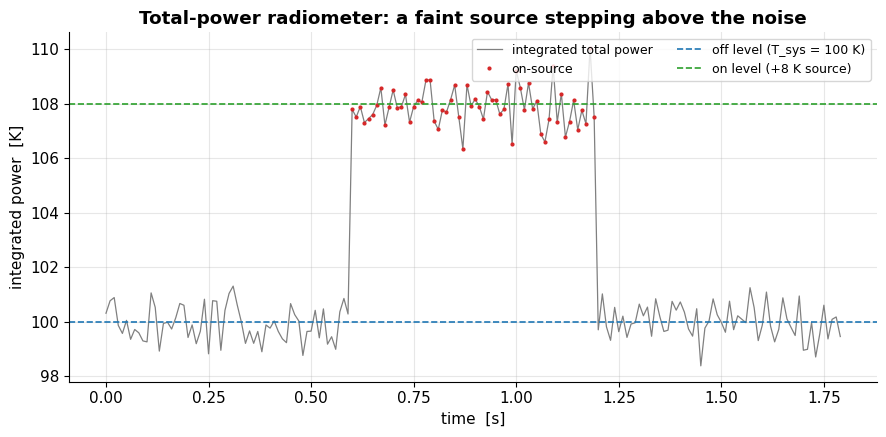

measured on-off step = 7.93 K  (true 8.00 K)
  significance = 88.2 sigma across the on segment


In [4]:
fig, ax = plt.subplots(figsize=(9, 4.5))

# Power is in "temperature" units (t_sys + signal); show it directly.
on = labels == "on"
ax.plot(t, power_series, lw=0.9, color="0.5", label="integrated total power")
ax.plot(t[on], power_series[on], lw=0, marker=".", ms=4, color="#d62728",
        label="on-source")

# Baselines: expected off (t_sys) and on (t_sys + t_src) levels.
ax.axhline(100.0, ls="--", color="#1f77b4", lw=1.2, label="off level (T_sys = 100 K)")
ax.axhline(108.0, ls="--", color="#2ca02c", lw=1.2, label="on level (+8 K source)")

ax.set_xlabel("time  [s]")
ax.set_ylabel("integrated power  [K]")
ax.set_title("Total-power radiometer: a faint source stepping above the noise")
ax.legend(loc="upper right", fontsize=9, ncol=2)
fig.tight_layout()
plt.show()

# Quantify the detection: mean on minus mean off, vs the noise on that difference.
mean_off = power_series[labels == "off"].mean()
mean_on = power_series[on].mean()
sem = power_series[on].std() / np.sqrt(on.sum())
print(f"measured on-off step = {mean_on - mean_off:.2f} K  (true 8.00 K)")
print(f"  significance = {(mean_on - mean_off)/sem:.1f} sigma across the on segment")

The single-dump scatter is several kelvin — larger than the 8 K source — yet the
**on segment sits cleanly above the off baseline**, and averaging the whole
on-source segment recovers the 8 K step at high significance. That is the
radiometer equation at work: each dump already integrates `B·τ = 2.4e6 × 0.01 ≈
24 000` independent samples, shrinking the noise by `√(Bτ)`, and averaging the
segment shrinks it further. This four-block chain *is* a total-power radio
telescope.

## 3. A spectrometer flowgraph

A total-power detector throws away *where* in the band the power is. To find a
**spectral line** — like neutral hydrogen at 1420.4 MHz — we need power **per
frequency channel**. That is the spectrometer flowgraph, the heart of DSPIRA,
CCERA, and PICTOR:

```
 ┌──────────┐  ┌──────────┐  ┌────────┐  ┌──────────────┐  ┌────────────┐  ┌──────┐
 │ IQ SOURCE│→ │ STREAM→  │→ │ WINDOW │→ │ FFT          │→ │ MAG² +     │→ │ SINK │
 │          │  │ VECTOR   │  │ (Hann) │  │ (channelise) │  │ ACCUMULATE │  │      │
 └──────────┘  └──────────┘  └────────┘  └──────────────┘  └────────────┘  └──────┘
```

- **Stream→vector** — `blocks.stream_to_vector`: chop the IQ stream into frames of
  `nfft` samples.
- **Window** — multiply each frame by a Hann window to suppress spectral leakage
  (`fft.window.hann`).
- **FFT** — `fft.fft_vcc`: transform each frame to `nfft` frequency channels.
- **Mag² + accumulate** — `complex_to_mag_squared` then sum many frames: this is
  the integrating spectrometer. More frames → smoother spectrum, and a faint line
  emerges from the noise just as in the total-power case, but channel by channel.

We add a faint **emission line** offset from band centre and watch it climb out of
the noise as we accumulate more frames.

In [5]:
# ---- SPECTROMETER SOURCE: noise + a faint narrowband emission line ------
def spectrometer_source(n_samples, *, fs, line_offset_hz, line_power,
                        noise_power, generator):
    '''Complex IQ: flat noise floor + a faint Gaussian-shaped spectral line.

    The line is a narrowband signal at `line_offset_hz` from band centre, built
    as a cluster of nearby tones so it occupies a few FFT channels (like a real
    Doppler-broadened HI line).
    '''
    sigma = np.sqrt(noise_power / 2.0)
    z = generator.normal(0, sigma, n_samples) + 1j * generator.normal(0, sigma, n_samples)
    t = np.arange(n_samples) / fs
    # A few closely spaced tones -> a line a few channels wide.
    n_tones = 40
    width_hz = 6e3
    for _ in range(n_tones):
        f = line_offset_hz + generator.normal(0, width_hz)
        phase = generator.uniform(0, 2 * np.pi)
        amp = np.sqrt(line_power / n_tones)
        z += amp * np.exp(1j * (2 * np.pi * f * t + phase))
    return z


# ---- BLOCKS: stream_to_vector -> window -> FFT -> mag^2 -> accumulate ----
def spectrometer(z, *, nfft, window):
    '''Run the channelising flowgraph; return accumulated power per channel.

    Returns (spectrum, waterfall): the all-frame average and the per-frame
    power array (time x channel) so we can also draw a waterfall.
    '''
    n_frames = len(z) // nfft
    frames = z[: n_frames * nfft].reshape(n_frames, nfft)   # stream_to_vector
    frames = frames * window                                # WINDOW (Hann)
    spectra = np.fft.fftshift(np.fft.fft(frames, axis=1), axes=1)  # FFT
    power = np.abs(spectra) ** 2                            # complex_to_mag_squared
    waterfall = power                                       # per-frame (time x chan)
    spectrum = power.mean(axis=0)                           # ACCUMULATE (average)
    return spectrum, waterfall


nfft = 1024
window = np.hanning(nfft)
# Coherent power gain of the window, to keep the noise floor calibrated.
fc = 1.4204e9   # Hz, near the HI line, for flavour
line_offset = 300e3  # Hz from band centre

z = spectrometer_source(
    nfft * 4000, fs=fs, line_offset_hz=line_offset,
    line_power=2.0, noise_power=100.0, generator=rng,
)
spectrum, waterfall = spectrometer(z, nfft=nfft, window=window)

# Channel frequency axis (RF), centred on fc.
chan_freq = fc + np.fft.fftshift(np.fft.fftfreq(nfft, d=1 / fs))
print(f"spectrometer: nfft={nfft}, {waterfall.shape[0]} frames accumulated, "
      f"channel width {fs/nfft/1e3:.2f} kHz")

spectrometer: nfft=1024, 4000 frames accumulated, channel width 2.34 kHz


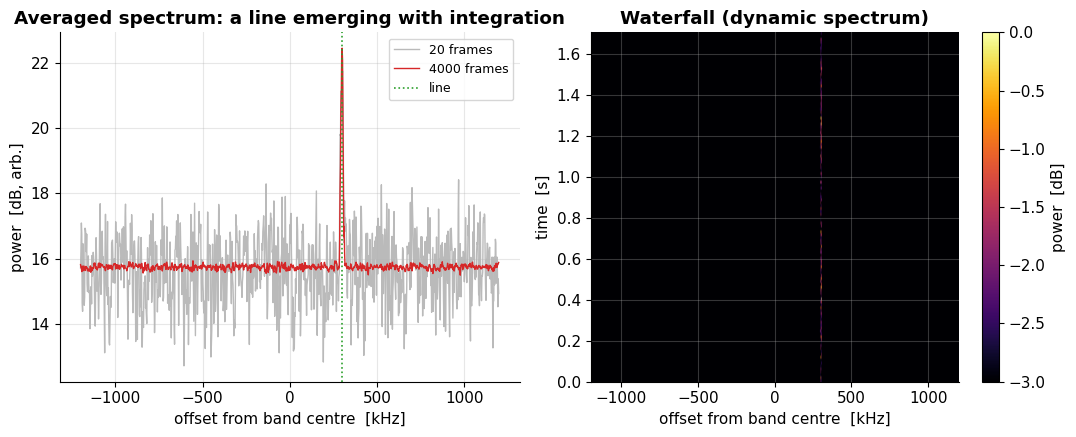

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# --- (a) averaged spectrum: line emerges over the noise floor ---
mhz = (chan_freq - fc) / 1e3  # offset from centre in kHz
ax = axes[0]
# Show progressively more integration to make "emerging" visible.
for n_acc, color, alpha in [(20, "0.7", 0.9), (4000, "#d62728", 1.0)]:
    spec_n = (np.abs(np.fft.fftshift(
        np.fft.fft(z[: n_acc * nfft].reshape(n_acc, nfft) * window, axis=1), axes=1)) ** 2
        ).mean(axis=0)
    ax.plot(mhz, 10 * np.log10(spec_n / spec_n.size),
            color=color, lw=1.0, alpha=alpha,
            label=f"{n_acc} frames")
ax.axvline(line_offset / 1e3, ls=":", color="#2ca02c", lw=1.2, label="line")
ax.set_xlabel("offset from band centre  [kHz]")
ax.set_ylabel("power  [dB, arb.]")
ax.set_title("Averaged spectrum: a line emerging with integration")
ax.legend(fontsize=9)

# --- (b) waterfall: power vs (time, channel) ---
ax = axes[1]
# Bin frames in time so the waterfall isn't 4000 rows tall.
n_rows = 120
rows = waterfall[: (waterfall.shape[0] // n_rows) * n_rows]
rows = rows.reshape(n_rows, -1, nfft).mean(axis=1)
extent = [mhz[0], mhz[-1], 0, rows.shape[0] * (waterfall.shape[0] / n_rows) * nfft / fs]
im = ax.imshow(10 * np.log10(rows / rows.max()), aspect="auto",
               extent=extent, cmap="inferno", vmin=-3, vmax=0)
ax.set_xlabel("offset from band centre  [kHz]")
ax.set_ylabel("time  [s]")
ax.set_title("Waterfall (dynamic spectrum)")
fig.colorbar(im, ax=ax, label="power  [dB]")
fig.tight_layout()
plt.show()

On the left, the faint line is buried in the 20-frame spectrum but stands proud
once 4000 frames are accumulated — the spectral analogue of the radiometer's
integrate-down. On the right, the waterfall shows the line as a steady vertical
stripe across all times (a real source is persistent; RFI tends to flicker). This
`source → window → FFT → mag² → accumulate` chain is, block for block, the DSPIRA
hydrogen-line spectrometer.

## 4. Exporting the flowgraph's output

A flowgraph's **sink** writes to disk. Two formats from
[Chapter 16](16_data_formats_and_ecosystem.ipynb) matter here, and
`jansky.formats` implements both:

- **SigMF** — the open Signal Metadata Format: raw IQ samples in a `.sigmf-data`
  file plus a JSON `.sigmf-meta` sidecar recording the sample rate and centre
  frequency. This is what you'd write straight off the **source** to archive a
  capture. (GNU Radio has a SigMF sink.)
- **GUPPI raw** — the Green Bank / Breakthrough Listen voltage format: complex
  8-bit samples ordered `[channel][time][polarisation]` behind an ASCII card
  header. This is what you'd write *after* the channeliser, so the captured
  voltages feed Chapter 16's GUPPI pipeline (and tools like `blimpy`/`rawspec`).

Let's wire both sinks and read them back to confirm the round-trip.

### SigMF sink — archive the raw IQ

We take a slice of the spectrometer's IQ source and write it as a SigMF recording,
tagging it with the sample rate and centre frequency, then read it back and
confirm the spectrum is unchanged.

In [7]:
from pathlib import Path
import tempfile

outdir = Path(tempfile.mkdtemp(prefix="jansky_ch28_"))

# --- SigMF SINK: write the captured IQ + metadata ---
iq_capture = z[: 200_000].astype(np.complex64)
meta_path, data_path = formats.write_sigmf(
    outdir / "capture",
    iq_capture,
    sample_rate=fs,
    center_freq=fc,
    extra_global={"core:description": "jansky Ch28 spectrometer capture",
                  "core:author": "jansky course"},
)
print(f"wrote {data_path.name} ({data_path.stat().st_size} bytes) + {meta_path.name}")

# --- read it back and verify ---
samples, meta = formats.read_sigmf(outdir / "capture")
print(f"read back {samples.size} samples, "
      f"sample_rate = {meta['global']['core:sample_rate']/1e6:.3f} Msps, "
      f"f_c = {meta['captures'][0]['core:frequency']/1e6:.4f} MHz")
assert np.allclose(samples, iq_capture, atol=1e-5), "SigMF round-trip mismatch!"
print("SigMF round-trip OK: samples identical to within float32 precision.")

wrote capture.sigmf-data (1600000 bytes) + capture.sigmf-meta
read back 200000 samples, sample_rate = 2.400 Msps, f_c = 1420.4000 MHz
SigMF round-trip OK: samples identical to within float32 precision.


### GUPPI raw sink — archive the channelised voltages

GUPPI raw stores **channelised** complex voltages, so we first run a small
polyphase-style channeliser (here just per-frame FFTs reshaped to
`[channel, time, pol]`) and quantise to the 8-bit range GUPPI uses. We scale the
voltages to use the int8 dynamic range, write a single block with the header cards
Breakthrough Listen expects (`OBSFREQ`, `OBSBW`, `TBIN`, ...), then read the header
and the voltages back.

In [8]:
# --- Channelise into a few coarse channels for a compact GUPPI example ---
n_chan = 16
gframes = z[: (len(z) // n_chan) * n_chan].reshape(-1, n_chan)
volts = np.fft.fft(gframes, axis=1)              # (ntime, nchan)
volts = volts.T[:, :, None]                       # -> (nchan, ntime, npol=1)

# Scale to use the int8 range (GUPPI stores 8-bit I/Q); avoid clipping.
scale = 100.0 / np.abs(volts).max()
volts_q = volts * scale

guppi_path = outdir / "flowgraph.0000.raw"
formats.write_guppi(
    guppi_path,
    volts_q,
    header={
        "OBSFREQ": fc / 1e6,        # MHz
        "OBSBW": fs / 1e6,          # MHz
        "TBIN": n_chan / fs,        # s per spectrum
        "TELESCOP": "JANSKY-GR",
        "SRC_NAME": "SIM_HI",
    },
)
print(f"wrote {guppi_path.name} ({guppi_path.stat().st_size} bytes)")

# --- read the header, then iterate the voltage blocks back ---
hdr = formats.read_guppi_header(guppi_path)
print(f"GUPPI header: OBSNCHAN={hdr['OBSNCHAN']}, NPOL={hdr['NPOL']}, "
      f"NBITS={hdr['NBITS']}, OBSFREQ={hdr['OBSFREQ']} MHz, "
      f"TBIN={hdr['TBIN']:.3e} s")

(rh, vback), = formats.iter_guppi_blocks(guppi_path)
print(f"read back voltages of shape {vback.shape} (nchan, ntime, npol)")
assert vback.shape[0] == n_chan and vback.shape[2] == 1
# The recovered channel structure should match (up to int8 quantisation).
recovered_chan_power = (np.abs(vback[:, :, 0]) ** 2).mean(axis=1)
print("per-channel mean power recovered from GUPPI (arb.):")
print(np.round(recovered_chan_power / recovered_chan_power.max(), 2))

wrote flowgraph.0000.raw (8192880 bytes)
GUPPI header: OBSNCHAN=16, NPOL=1, NBITS=8, OBSFREQ=1420.4 MHz, TBIN=6.667e-06 s
read back voltages of shape (16, 256000, 1) (nchan, ntime, npol)
per-channel mean power recovered from GUPPI (arb.):
[0.76 0.76 1.   0.76 0.76 0.76 0.76 0.76 0.76 0.76 0.76 0.76 0.76 0.76
 0.76 0.76]


The SigMF sidecar carries the calibration (sample rate, centre frequency) you need
to put a frequency axis on the IQ, and the GUPPI header carries `OBSFREQ`, `OBSBW`,
and `TBIN` so the channelised voltages slot straight into the Chapter 16 pipeline.
A real flowgraph just wires these writers as sinks; the bytes on disk are
identical.

## 5. Try it yourself

1. **Add a bandpass-filter block.** Real flowgraphs put a `filter.fir_filter_ccf`
   between source and detector to keep only the band of interest. Insert a
   `scipy.signal.firwin` FIR filter into the total-power chain
   (`source → FILTER → detect → integrate`) and show that filtering out a band of
   pure noise *lowers* `T_sys` and so improves the on/off significance.

2. **Vary the integration and watch the radiometer equation.** Re-run the
   total-power flowgraph for `decimation ∈ {6000, 24000, 96000}` and plot the
   measured on/off step's scatter against `1/√(B·τ)`. Confirm it falls on the
   `signals.radiometer_sensitivity()` line — the same `√(Bτ)` law that governs
   spectrometer integration.

3. **Make a fake RFI burst and tell it from the line.** Add a *transient* tone to
   `spectrometer_source` that is only present in some frames, re-draw the
   waterfall, and show that time-averaging suppresses the flickering RFI while the
   persistent line survives — the standard "is it real?" test for amateur HI
   detections.

## Recap & what's next

We rebuilt two radio-astronomy back-ends as **GNU Radio flowgraphs**, modelled
block-by-block in NumPy so they run on the base environment:

- A **total-power radiometer** — `source → square-law detect → integrate & dump →
  sink` — and watched a faint source step above the noise exactly as the
  [Chapter 3](03_signals_noise_radiometer.ipynb) radiometer equation predicts.
- A **spectrometer** — `source → window → FFT → mag² → accumulate → sink` — and
  watched a spectral line emerge from the noise with integration, shown as both an
  averaged spectrum and a waterfall.
- Two **sinks**: a **SigMF** recording of the raw IQ and a **GUPPI raw** file of
  the channelised voltages, both written and read back with `jansky.formats` so a
  flowgraph's output feeds the [Chapter 16](16_data_formats_and_ecosystem.ipynb)
  pipeline.

The **real `.grc` flowgraphs** — and the `gr-osmosdr` drivers to run them against a
live dongle — live in the GNU Radio container,
[`containers/gnuradio.Dockerfile`](../containers/gnuradio.Dockerfile). Open them in
GNU Radio Companion to see these exact blocks wired on a canvas, and compare them
with the DSPIRA, CCERA, PICTOR, and `srt-py` designs in
[`docs/projects.md`](../docs/projects.md). With flowgraphs demystified, you can now
read, modify, or build the back-end of any educational radio telescope — and every
byte it writes is a format you already know.